# Phase-separated thermalization state inspector

Select an existing thermalization state by reduced temperature `kT`, target density, and FCC cell count. The notebook loads its saved GSD frame, builds a voxel-density histogram, fits the repository's gas + liquid + interface mixture model, and reports two liquid/gas ratios with covariance-propagated uncertainties.

- **Density contrast:** fitted liquid density divided by fitted gas density.
- **Phase voxel ratio:** liquid-assigned voxel fraction divided by gas-assigned voxel fraction. By default, half of the fitted interface voxels are assigned to each phase.

Uncertainties use the delta method with the complete fitted-parameter covariance matrix, so parameter correlations are retained.

In [1]:
from pathlib import Path

import gsd.hoomd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers.paths import THERMALIZED_STATES_V3_ROOT, thermalized_run_paths
from md_Helpers.spatial import nbins_for_ncells
from md_Helpers.visualization import plot_voxel_mixture_fit
from md_Helpers.voxel_fit import fit_last_frame_voxel_histogram

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 1. Choose a saved state

Edit the first three values to inspect a different state. `kT` is the reduced simulation temperature used in the repository paths. The defaults below correspond to the thermalized `ncell=10`, `rho=0.68`, `kT=0.8` state previously classified as phase separated in `Fixing_Phase_Sep.ipynb`.

In [6]:
# Primary selectors
KT = 0.800
TARGET_RHO = 0.70
N_FCC_CELLS = 30

# Saved-run selectors
NSTEPS = 1_000_000
SEED = 1
PHASE_NAME = "randomization"
THERMALIZED_ROOT = Path(THERMALIZED_STATES_V3_ROOT)

# Analysis settings
FRAME_INDEX = -1
VOXEL_NBINS = nbins_for_ncells(N_FCC_CELLS)  # Set an integer to override.
INTERFACE_TO_GAS = 0.5  # The remaining 0.5 is assigned to liquid.
INTERFACE_QUADRATURE_POINTS = 40
MAX_FIT_ITERATIONS = 500

if not 0.0 <= INTERFACE_TO_GAS <= 1.0:
    raise ValueError("INTERFACE_TO_GAS must be between 0 and 1")

print(f"Selected: kT={KT}, rho={TARGET_RHO}, ncell={N_FCC_CELLS}")
print(f"Voxel grid: {VOXEL_NBINS} x {VOXEL_NBINS} x {VOXEL_NBINS}")

Selected: kT=0.8, rho=0.7, ncell=30
Voxel grid: 12 x 12 x 12


## 2. Resolve and inspect the saved GSD state

In [7]:
paths = thermalized_run_paths(
    n_fcc_cells=N_FCC_CELLS,
    target_rho=TARGET_RHO,
    kT=KT,
    nsteps=NSTEPS,
    seed=SEED,
    phase_name=PHASE_NAME,
    base_folder=THERMALIZED_ROOT,
)
state_path = Path(paths["state_path"])
print(state_path)

if not state_path.exists():
    raise FileNotFoundError(
        f"No saved thermalization state at {state_path}. "
        "Check KT, TARGET_RHO, N_FCC_CELLS, NSTEPS, SEED, and THERMALIZED_ROOT."
    )

with gsd.hoomd.open(name=str(state_path), mode="r") as trajectory:
    n_frames = len(trajectory)
    frame = trajectory[FRAME_INDEX]

state_summary = pd.Series({
    "path": str(state_path),
    "frames_in_file": n_frames,
    "selected_frame": FRAME_INDEX,
    "timestep": int(frame.configuration.step),
    "particles": int(frame.particles.N),
    "box_Lx": float(frame.configuration.box[0]),
    "box_Ly": float(frame.configuration.box[1]),
    "box_Lz": float(frame.configuration.box[2]),
})
state_summary

/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.700/kT_0.800/nsteps_1000000/seed_1/randomization.gsd


path              /exp/e961/data/MDsims-data/pnichols/Thermalize...
frames_in_file                                                    1
selected_frame                                                   -1
timestep                                                    1000000
particles                                                    108000
box_Lx                                                    53.634212
box_Ly                                                    53.634212
box_Lz                                                    53.634212
dtype: object

## 3. Fit and plot the voxel-density histogram

The gas component is Poisson, the liquid component is a discretized Gaussian, and the interface component integrates mixtures between the fitted gas and liquid states. The lower panel shows data-minus-fit residuals.

Fit success: True
Optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
AIC: 10779.10; BIC: 10806.37


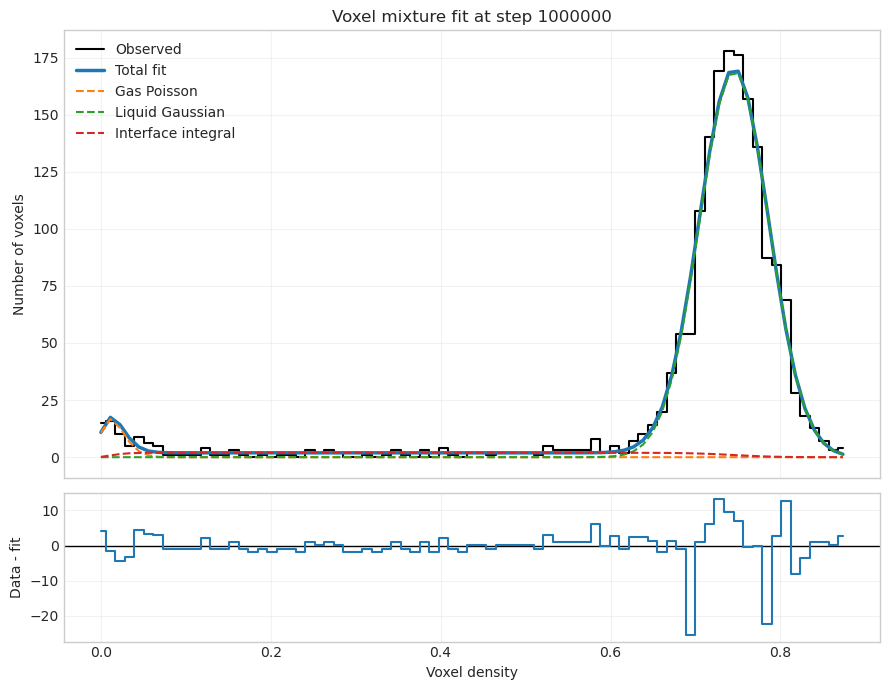

In [12]:
fit = fit_last_frame_voxel_histogram(
    trajectory_path=state_path,
    frame_index=FRAME_INDEX,
    voxel_nbins=VOXEL_NBINS,
    interface_points=INTERFACE_QUADRATURE_POINTS,
    max_iterations=MAX_FIT_ITERATIONS,
)

print(f"Fit success: {fit['success']}")
print(f"Optimizer message: {fit['message']}")
print(f"AIC: {fit['AIC']:.2f}; BIC: {fit['BIC']:.2f}")
plot_voxel_mixture_fit(fit, x_axis="density", show_residuals=True, figsize=(9, 7))

In [13]:
fit_summary = pd.Series({
    "gas density": fit["gas_density"],
    "liquid density": fit["liquid_density"],
    "liquid density fit SE": fit["liquid_density_uncertainty"],
    "liquid Gaussian width": fit["liquid_sigma_density"],
    "gas mixture weight": fit["gas_weight"],
    "liquid mixture weight": fit["liquid_weight"],
    "interface mixture weight": fit["interface_weight"],
    "voxel volume": fit["voxel_volume"],
    "number of voxels": fit["n_voxels"],
})
fit_summary

gas density                    0.017335
liquid density                 0.745524
liquid density fit SE          0.001078
liquid Gaussian width          0.040837
gas mixture weight             0.029299
liquid mixture weight          0.898549
interface mixture weight       0.072153
voxel volume                  89.285716
number of voxels            1728.000000
dtype: float64

## 4. Propagate fit uncertainty to the ratios

The optimizer fits five transformed parameters: log gas mean, log liquid-minus-gas mean, log liquid width, gas/interface log-weight ratio, and liquid/interface log-weight ratio. The covariance matrix is expressed in those coordinates. The gradients below are therefore taken in the same coordinates.

For a positive ratio, the reported 95% interval is calculated in log-ratio space. This avoids an unphysical negative lower limit.

In [14]:
def propagate_positive_ratio(ratio, gradient, covariance, confidence_z=1.96):
    """First-order covariance propagation with a log-scale confidence interval."""
    gradient = np.asarray(gradient, dtype=float)
    covariance = np.asarray(covariance, dtype=float)
    variance = float(gradient @ covariance @ gradient)
    if not np.isfinite(variance) or variance < 0.0:
        return {
            "estimate": float(ratio), "standard_error": np.nan,
            "ci95_low": np.nan, "ci95_high": np.nan,
        }

    standard_error = float(np.sqrt(variance))
    log_standard_error = standard_error / float(ratio)
    return {
        "estimate": float(ratio),
        "standard_error": standard_error,
        "ci95_low": float(ratio * np.exp(-confidence_z * log_standard_error)),
        "ci95_high": float(ratio * np.exp(confidence_z * log_standard_error)),
    }


def liquid_gas_ratio_uncertainties(fit, interface_to_gas=0.5):
    """Return density-contrast and interface-adjusted phase-ratio uncertainty."""
    covariance = np.asarray(fit["parameter_covariance"], dtype=float)
    if covariance.shape != (5, 5):
        raise ValueError(f"Expected a 5x5 parameter covariance, found {covariance.shape}")

    # Density contrast R_rho = liquid_mean / gas_mean. Voxel volume cancels.
    gas_mean = float(fit["gas_mean_count"])
    liquid_mean = float(fit["liquid_mean_count"])
    density_ratio = liquid_mean / gas_mean
    mean_gap_over_gas = (liquid_mean - gas_mean) / gas_mean
    density_gradient = np.array([
        -mean_gap_over_gas, mean_gap_over_gas, 0.0, 0.0, 0.0
    ])

    # Softmax-weight derivatives with respect to gas and liquid logits.
    gas_weight = float(fit["gas_weight"])
    liquid_weight = float(fit["liquid_weight"])
    interface_weight = float(fit["interface_weight"])
    weight_jacobian = np.array([
        [gas_weight * (1.0 - gas_weight), -gas_weight * liquid_weight],
        [-liquid_weight * gas_weight, liquid_weight * (1.0 - liquid_weight)],
        [-interface_weight * gas_weight, -interface_weight * liquid_weight],
    ])

    interface_to_liquid = 1.0 - float(interface_to_gas)
    effective_gas = gas_weight + interface_to_gas * interface_weight
    effective_liquid = liquid_weight + interface_to_liquid * interface_weight
    phase_ratio = effective_liquid / effective_gas

    d_gas = weight_jacobian[0] + interface_to_gas * weight_jacobian[2]
    d_liquid = weight_jacobian[1] + interface_to_liquid * weight_jacobian[2]
    d_phase_ratio = (
        d_liquid * effective_gas - effective_liquid * d_gas
    ) / effective_gas**2
    phase_gradient = np.array([0.0, 0.0, 0.0, *d_phase_ratio])

    return {
        "density_contrast": propagate_positive_ratio(
            density_ratio, density_gradient, covariance
        ),
        "phase_voxel_ratio": propagate_positive_ratio(
            phase_ratio, phase_gradient, covariance
        ),
        "effective_gas_fraction": effective_gas,
        "effective_liquid_fraction": effective_liquid,
        "interface_to_gas": float(interface_to_gas),
        "interface_to_liquid": interface_to_liquid,
    }

In [15]:
ratios = liquid_gas_ratio_uncertainties(
    fit, interface_to_gas=INTERFACE_TO_GAS
)

ratio_table = pd.DataFrame.from_dict(
    {
        r"Density contrast $\rho_l/\rho_g$": ratios["density_contrast"],
        r"Phase voxel ratio $V_l/V_g$": ratios["phase_voxel_ratio"],
    },
    orient="index",
)
ratio_table.index.name = "quantity"
display(ratio_table)

allocation_table = pd.DataFrame({
    "phase": ["gas", "liquid"],
    "effective_fraction": [
        ratios["effective_gas_fraction"],
        ratios["effective_liquid_fraction"],
    ],
})
allocation_table["effective_voxels"] = (
    allocation_table["effective_fraction"] * fit["n_voxels"]
)
display(allocation_table.set_index("phase"))

print(
    f"Interface allocation: {100 * ratios['interface_to_gas']:.1f}% gas, "
    f"{100 * ratios['interface_to_liquid']:.1f}% liquid"
)

,estimate,standard_error,ci95_low,ci95_high
quantity,,,,
Density contrast $\rho_l/\rho_g$,43.007985,7.801945,30.13925,61.371362
Phase voxel ratio $V_l/V_g$,14.296410,1.247836,12.04842,16.963831


,effective_fraction,effective_voxels
phase,,
gas,0.065375,112.96768
liquid,0.934625,1615.03232


Interface allocation: 50.0% gas, 50.0% liquid


## Interpretation and uncertainty limits

- The density contrast and phase voxel ratio answer different questions. Interface allocation changes only the phase voxel ratio.
- The standard errors above reflect local fit-parameter uncertainty and correlation from the likelihood Hessian.
- They do not include model-choice uncertainty, voxel-resolution sensitivity, or spatial correlation between neighboring voxels.
- Check the residual plot and repeat with nearby voxel resolutions before treating the result as physical. If multiple independent frames or seeds are available, a frame/seed bootstrap is preferable for the final uncertainty.